In [1]:
#..............................
### Entendimiento del negocio ###
#..............................
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Codificar la entidad
import category_encoders as ce
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_squared_error, r2_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("C:\\Users\\JanBA\\Proyectos\\incidencia-delictiva\\data\\incidencia_delictiva.csv")
print(df.columns)
print(df.head())

Index(['anio', 'clave_ent', 'entidad', 'bien_juridico_afectado', 'tipo_delito',
       'subtipo_delito', 'modalidad', 'mes', 'fecha', 'incidencia_delictiva',
       'entidad_federativa', 'temporal_fecha', '..anio_fecha'],
      dtype='str')
   anio  clave_ent         entidad bien_juridico_afectado tipo_delito  \
0  2023          1  Aguascalientes          El patrimonio        Robo   
1  2023          1  Aguascalientes          El patrimonio        Robo   
2  2023          1  Aguascalientes          El patrimonio        Robo   
3  2023          1  Aguascalientes          El patrimonio        Robo   
4  2023          1  Aguascalientes          El patrimonio        Robo   

  subtipo_delito      modalidad        mes       fecha  incidencia_delictiva  \
0    Otros robos  Con violencia      Abril  2023-04-01                     0   
1    Otros robos  Con violencia     Agosto  2023-08-01                     0   
2    Otros robos  Con violencia  Diciembre  2023-12-01                     0   


**incidencia_delictiva >** del mes anterior para cada 'entidad',  para capturar la dependencia temporal de los datos.

In [3]:
#..............................
### Limpieza y preparación de datos ###
#..............................
# Filtrar por años específicos
df = df[df['anio'].isin([2022,2023])]
# Filtrar por tipo de delito, especificar el problema
df = df[df['tipo_delito'].str.contains("Robo", case=False, na=False)]

# Agrupar por entidad, año y mes, sumando la incidencia delictiva
dfg = df.groupby(['entidad', 'anio', 'mes'])['incidencia_delictiva'].sum().reset_index()

print("df agrupado")
dfg.head()

df agrupado


,entidad,anio,mes,incidencia_delictiva
0,Aguascalientes,2023,Abril,929
1,Aguascalientes,2023,Agosto,997
2,Aguascalientes,2023,Diciembre,841
3,Aguascalientes,2023,Enero,977
4,Aguascalientes,2023,Febrero,820


**.shift() >** desplaza los valores de una serie o DataFrame a lo largo del índice. Cuando le pasas 1 como argumento (.shift(1)), desplaza los valores hacia abajo una posición. Esto es útil para crear características basadas en valores anteriores, como en este caso, donde queremos comparar la incidencia delictiva actual con la del mes anterior.

In [4]:
#..............................
### Feature Engineering ###
#..............................

mes_map = {     # Convertir mes a número
    'Enero':1, 'Febrero':2, 'Marzo':3, 'Abril':4,
    'Mayo':5, 'Junio':6, 'Julio':7, 'Agosto':8,
    'Septiembre':9, 'Octubre':10, 'Noviembre':11, 'Diciembre':12
}
dfg['mes_num'] = dfg['mes'].map(mes_map)

# Ordenar antes de features
dfg = dfg.sort_values(by=['entidad','anio','mes'])

# Estacionalidad cíclica
dfg['sen_mes'] = np.sin(2 * np.pi * dfg['mes_num'] / 12)
dfg['cos_mes'] = np.cos(2 * np.pi * dfg['mes_num'] / 12)

dfg.drop(columns=['mes', 'anio'], inplace=True)
dfg.head(3)


,entidad,incidencia_delictiva,mes_num,sen_mes,cos_mes
0,Aguascalientes,929,4,8.660254e-01,-0.5
1,Aguascalientes,997,8,-8.660254e-01,-0.5
2,Aguascalientes,841,12,-2.449294e-16,1.0


In [5]:
# Lag (mes anterior por estado)
dfg['lag_1'] = dfg.groupby('entidad')['incidencia_delictiva'].shift(1)

# Cambio porcentual entre el elemento actual y uno anterior (tasa de crecimiento)
dfg['pct_change'] = dfg.groupby('entidad')[
    'incidencia_delictiva'].pct_change()    # Detecta picos o caídas

# Rolling mean (memoria histórica, promedio de últimos 3 meses, media móvil)
dfg['rolling_3'] = (
    dfg.groupby('entidad')['incidencia_delictiva']
    .rolling(3).mean().reset_index(0, drop=True)
)

# Diferencia absoluta (Señal fuerte de cambio reciente)
dfg['diff_1'] = dfg['incidencia_delictiva'] - dfg['lag_1']

# Tendencia temporal (Para ver si el crimen va subiendo o bajando con el tiempo)
dfg['tendencia'] = dfg.groupby('entidad').cumcount()

### Targets ###
# Clasificación (alto crimen)
dfg['alto_crimen'] = (
    dfg['incidencia_delictiva'] > 
    dfg.groupby('entidad')['incidencia_delictiva'].transform('median')
).astype(int)

# cuando un valor es mucho más alto que su comportamiento normal
# Anomalía = supera la media + 1 desviación estándar dentro de su entidad

media = dfg.groupby('entidad')['incidencia_delictiva'].transform('mean')
std   = dfg.groupby('entidad')['incidencia_delictiva'].transform('std')
dfg['anomalia'] = (
    dfg['incidencia_delictiva'] > media + std).astype(int)

# dfg['z_score'] = (dfg['incidencia_delictiva'] - media) / std
# dfg['anomalia'] = (dfg['z_score'] > 2).astype(int)
#-------------------------------------------------------------------------
# Eliminar nulos
dfg.fillna(0, inplace=True)

print(dfg['anomalia'].value_counts())
print(dfg['anomalia'].value_counts(normalize=True).mul(100).round(1))
dfg.head()

anomalia
0    325
1     59
Name: count, dtype: int64
anomalia
0    84.6
1    15.4
Name: proportion, dtype: float64


,entidad,incidencia_delictiva,mes_num,sen_mes,cos_mes,lag_1,pct_change,rolling_3,diff_1,tendencia,alto_crimen,anomalia
0,Aguascalientes,929,4,8.660254e-01,-0.500000,0.0,0.000000,0.000000,0.0,0,0,0
1,Aguascalientes,997,8,-8.660254e-01,-0.500000,929.0,0.073197,0.000000,68.0,1,1,1
2,Aguascalientes,841,12,-2.449294e-16,1.000000,997.0,-0.156469,922.333333,-156.0,2,0,0
3,Aguascalientes,977,1,5.000000e-01,0.866025,841.0,0.161712,938.333333,136.0,3,1,0
4,Aguascalientes,820,2,8.660254e-01,0.500000,977.0,-0.160696,879.333333,-157.0,4,0,0


In [6]:
# Targets 
y_class_cr = dfg['alto_crimen']
y_class_an = dfg['anomalia']
y_reg      = dfg['incidencia_delictiva']

# Features
X = dfg.drop(columns=['alto_crimen', 'incidencia_delictiva', 'anomalia'])
X.head()

,entidad,mes_num,sen_mes,cos_mes,lag_1,pct_change,rolling_3,diff_1,tendencia
0,Aguascalientes,4,8.660254e-01,-0.500000,0.0,0.000000,0.000000,0.0,0
1,Aguascalientes,8,-8.660254e-01,-0.500000,929.0,0.073197,0.000000,68.0,1
2,Aguascalientes,12,-2.449294e-16,1.000000,997.0,-0.156469,922.333333,-156.0,2
3,Aguascalientes,1,5.000000e-01,0.866025,841.0,0.161712,938.333333,136.0,3
4,Aguascalientes,2,8.660254e-01,0.500000,977.0,-0.160696,879.333333,-157.0,4


In [7]:
#..............................
### Preprocesing ###
#..............................
# Un solo split
X_train, X_test, ycc_train, ycc_test, yca_train, yca_test, yr_train, yr_test = train_test_split(
    X, y_class_cr, y_class_an, y_reg,
    test_size=0.2, random_state=42)

#....................................................
# Target Encoding
def aplicar_encoding(X_train, X_test, y_train, col='entidad'):
    enc = ce.TargetEncoder(cols=[col])
    Xtr = X_train.copy()
    Xte  = X_test.copy()

    Xtr['entidad_enc'] = enc.fit_transform(Xtr[col], y_train)
    Xte['entidad_enc'] = enc.transform(Xte[col])
    Xtr = Xtr.drop(columns=[col])
    Xte = Xte.drop(columns=[col])

    return Xtr, Xte, enc

Xcc_train, Xcc_test, enc_cc = aplicar_encoding(X_train, X_test, ycc_train)
Xca_train, Xca_test, enc_ca = aplicar_encoding(X_train, X_test, yca_train)
Xr_train,  Xr_test,  enc_r  = aplicar_encoding(X_train, X_test, yr_train)

print(Xcc_train.head())

     mes_num   sen_mes   cos_mes   lag_1  pct_change    rolling_3  diff_1  \
165       11 -0.500000  0.866025  3504.0    0.028539  3623.333333   100.0   
322       10 -0.866025  0.500000   792.0   -0.020202   783.000000   -16.0   
220        2  0.866025  0.500000  1122.0   -0.138146   951.333333  -155.0   
94        10 -0.866025  0.500000   485.0    0.053608   509.666667    26.0   
232        2  0.866025  0.500000   993.0   -0.172205   827.666667  -171.0   

     tendencia  entidad_enc  
165          9     0.528085  
322         10     0.514297  
220          4     0.488019  
94          10     0.515096  
232          4     0.515096  


In [8]:
#..............................
### Clasificación Alto Crimen ###
#..............................

param_grid_lr = {           # Logistic Regresion
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500]
}

grid_cc = GridSearchCV(     # GridSearch
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='f1',   # f1 es mejor que accuracy para clases desbalanceadas
    n_jobs=-1
)
grid_cc.fit(Xcc_train, ycc_train)
pred_cc = grid_cc.predict(Xcc_test)

print("═══ CLASIFICACIÓN: alto_crimen ═══")
print(f"Mejores params : {grid_cc.best_params_}")
print(f"Accuracy       : {accuracy_score(ycc_test, pred_cc):.4f}")
print(classification_report(ycc_test, pred_cc))


═══ CLASIFICACIÓN: alto_crimen ═══
Mejores params : {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Accuracy       : 0.7662
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        40
           1       0.73      0.81      0.77        37

    accuracy                           0.77        77
   macro avg       0.77      0.77      0.77        77
weighted avg       0.77      0.77      0.77        77



In [9]:
#grid_ca.fit(Xca_train, yca_train)
#pred_ca = grid_ca.predict(Xca_test)

#print("═══ CLASIFICACIÓN: anomalia ═══")
#print(f"Mejores params : {grid_ca.best_params_}")
#print(f"Accuracy       : {accuracy_score(yca_test, pred_ca):.4f}")
#print(classification_report(yca_test, pred_ca))


In [10]:
#..............................
### Clasificación Anomalía ###
#..............................
# class_weight='balanced' penaliza más los errores en la clase minoritaria

grid_ca = GridSearchCV(     # GridSearch
    LogisticRegression(class_weight='balanced'),
    param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
sm = SMOTE(random_state=42)
Xca_train_bal, yca_train_bal = sm.fit_resample(
    Xca_train, yca_train)
print("Balance tras SMOTE:")
print(pd.Series(yca_train_bal).value_counts())

# Luego se entrena normalmente con los datos balanceados
grid_ca.fit(Xca_train_bal, yca_train_bal)
pred_ca = grid_ca.predict(Xca_test)

print("═══ CLASIFICACIÓN: anomalia ═══")
print(f"Mejores params : {grid_ca.best_params_}")
print(f"Accuracy       : {accuracy_score(yca_test, pred_ca):.4f}")
print(classification_report(yca_test, pred_ca))

Balance tras SMOTE:
anomalia
0    261
1    261
Name: count, dtype: int64
═══ CLASIFICACIÓN: anomalia ═══
Mejores params : {'C': 10, 'max_iter': 200, 'solver': 'liblinear'}
Accuracy       : 0.8052
              precision    recall  f1-score   support

           0       0.98      0.78      0.87        64
           1       0.46      0.92      0.62        13

    accuracy                           0.81        77
   macro avg       0.72      0.85      0.74        77
weighted avg       0.89      0.81      0.83        77



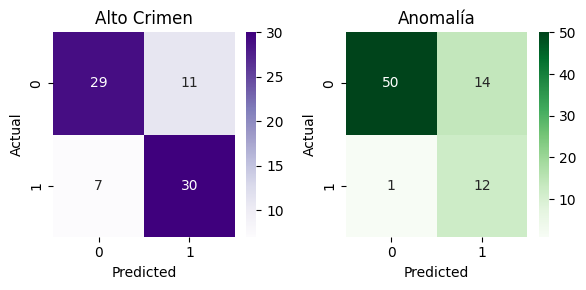

anomalia
0    325
1     59
Name: count, dtype: int64
anomalia
0    0.846354
1    0.153646
Name: proportion, dtype: float64


In [11]:
# Confusión Matrix
CMcc = confusion_matrix(ycc_test, grid_cc.predict(Xcc_test))
CMca = confusion_matrix(yca_test, grid_ca.predict(Xca_test))

plt.figure(figsize=(6, 3))
plt.subplot(1,2,1)
sns.heatmap(CMcc, annot=True, fmt='d', cmap='Purples')
plt.title('Alto Crimen')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(CMca, annot=True, fmt='d', cmap='Greens')
plt.title('Anomalía')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

print(y_class_an.value_counts())
print(y_class_an.value_counts(normalize=True))

In [12]:
#..............................
### Regresión ###
#..............................
# Ridge en ves de Linear Regression
# ya que no tiene regularización, puede sobreajustar

param_grid_ridge = {'alpha': [0.1, 1, 10, 100, 500]}    
grid_ridge = GridSearchCV(          # Ridge
    Ridge(), param_grid_ridge, cv=5, scoring='r2', n_jobs=-1
)
grid_ridge.fit(Xr_train, yr_train)
pred_ridge = grid_ridge.predict(Xr_test)    
print("═══ REGRESIÓN: Ridge ═══")
print(f"Mejor alpha : {grid_ridge.best_params_}")
print(f"R²          : {r2_score(yr_test, pred_ridge):.4f}")
print(f"RMSE        : {np.sqrt(mean_squared_error(yr_test, pred_ridge)):.4f}")
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
param_grid_rf = {           # RandomForestRegressor 
    'n_estimators': [100, 200], 'max_depth': [None, 5, 10],'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5, scoring='r2', n_jobs=-1
)
grid_rf.fit(Xr_train, yr_train)
pred_rf = grid_rf.predict(Xr_test)
print("═══ REGRESIÓN: RandomForest ═══")
print(f"Mejores params : {grid_rf.best_params_}")
print(f"R²             : {r2_score(yr_test, pred_rf):.4f}")
print(f"RMSE           : {np.sqrt(mean_squared_error(yr_test, pred_rf)):.4f}")


═══ REGRESIÓN: Ridge ═══
Mejor alpha : {'alpha': 500}
R²          : 0.9739
RMSE        : 358.2466
═══ REGRESIÓN: RandomForest ═══
Mejores params : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
R²             : 0.9965
RMSE           : 130.7595


In [13]:
importancias = pd.Series(
    grid_rf.best_estimator_.feature_importances_,
    index=Xr_train.columns
).sort_values(ascending=False)

print("═══ IMPORTANCIA DE VARIABLES ═══")
print(importancias)

═══ IMPORTANCIA DE VARIABLES ═══
entidad_enc    0.819102
lag_1          0.146453
rolling_3      0.030899
diff_1         0.001216
pct_change     0.001131
mes_num        0.000399
cos_mes        0.000354
sen_mes        0.000301
tendencia      0.000146
dtype: float64


> ¿Qué estados tienen más riesgo?

In [14]:
df_eval         = Xr_test.copy()
df_eval['real'] = yr_test   # Real de regresión
df_eval['pred'] = pred_rf   # Predicciones

riesgo_modelo = df_eval.groupby(dfg['entidad'])[['real', 'pred']].mean()
riesgo_modelo['error'] = riesgo_modelo['pred'] - riesgo_modelo['real']

print("═══ Incidencia Delictiva x Entidad ═══")
riesgo_modelo.sort_values('pred', ascending=False).head(20)

═══ Incidencia Delictiva x Entidad ═══


,real,pred,error
entidad,,,
México,10994.000000,10598.853430,-395.146570
Ciudad de México,6252.000000,6193.766480,-58.233520
Jalisco,3334.000000,3484.858569,150.858569
Baja California,2756.666667,2767.081721,10.415054
Puebla,2672.500000,2701.353088,28.853088
Guanajuato,2502.000000,2613.120249,111.120249
Querétaro,1980.000000,1950.951667,-29.048333
Veracruz de Ignacio de la Llave,1611.666667,1511.492014,-100.174653
San Luis Potosí,1257.000000,1346.310382,89.310382


> ¿Hay estacionalidad?

<Axes: xlabel='entidad'>

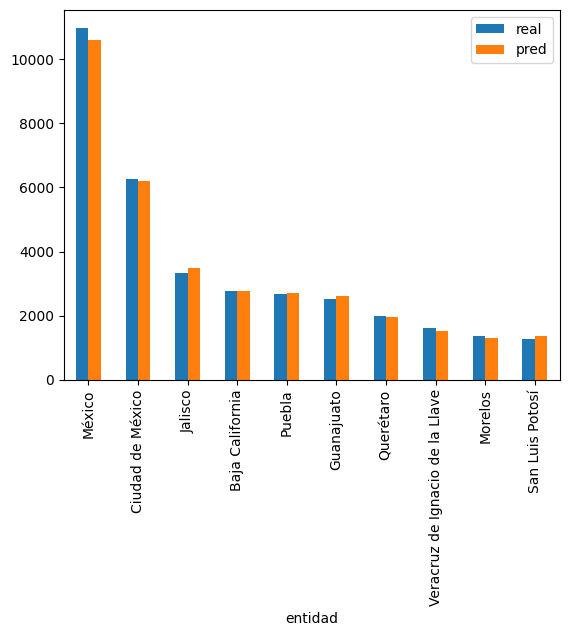

In [15]:
riesgo_modelo[['real', 'pred']].sort_values(
    'real', ascending=False
    ).head(10).plot(kind='bar')

In [20]:
df_eval['mes_num'] = dfg.loc[Xr_test.index, 'mes_num']
df_eval['mes'] = df.loc[Xr_test.index, 'mes']
df_eval['entidad'] = dfg.loc[Xr_test.index, 'entidad']
df_eval['error'] = df_eval['pred'] - df_eval['real']
df_eval.head(3)

,mes_num,sen_mes,cos_mes,lag_1,pct_change,rolling_3,diff_1,tendencia,entidad_enc,real,pred,mes,entidad,error
268,2,0.866025,5.000000e-01,1310.0,-0.053435,1198.333333,-70.0,4,1388.221600,1240,1163.558431,Febrero,Quintana Roo,-76.441569
250,10,-0.866025,5.000000e-01,2505.0,0.093413,2674.333333,234.0,10,1737.306957,2739,2788.000192,Octubre,Puebla,49.000192
355,3,1.000000,6.123234e-17,1521.0,0.140697,1586.000000,214.0,7,1478.351387,1735,1513.068816,Marzo,Veracruz de Ignacio de la Llave,-221.931184


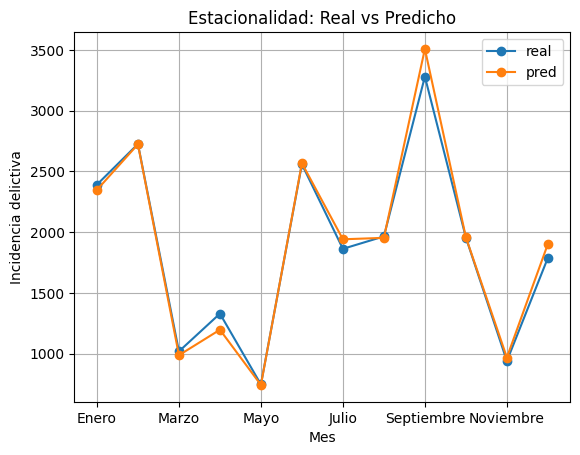

In [17]:
estacionalidad = df_eval.groupby('mes_num')[['real', 'pred']].mean()

mes_map_inv = {
    1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',
    5:'Mayo',6:'Junio',7:'Julio',8:'Agosto',
    9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'
}
estacionalidad.index = estacionalidad.index.map(mes_map_inv)

estacionalidad.plot(kind='line', marker='o')
plt.title('Estacionalidad: Real vs Predicho')
plt.xlabel('Mes')
plt.ylabel('Incidencia delictiva')
plt.grid(True)
plt.show()


In [ ]:
# Guardar datos y resultados
df_eval.to_csv('resultados_modelo.csv', index=False)

: 